<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

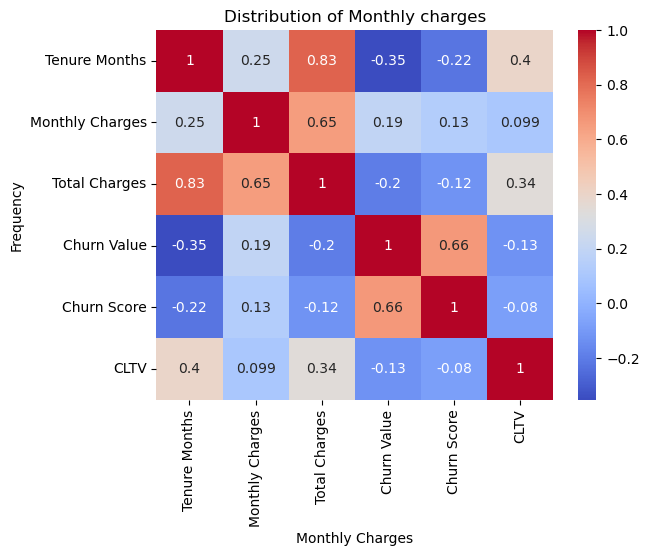

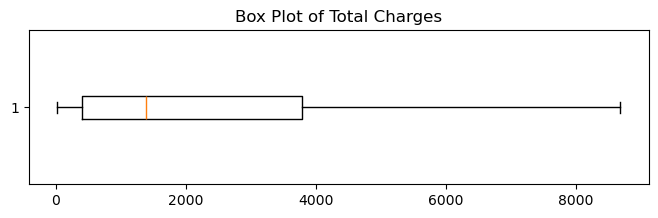

Skewness: 0.9637890936414896
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}
0.8485006245183236


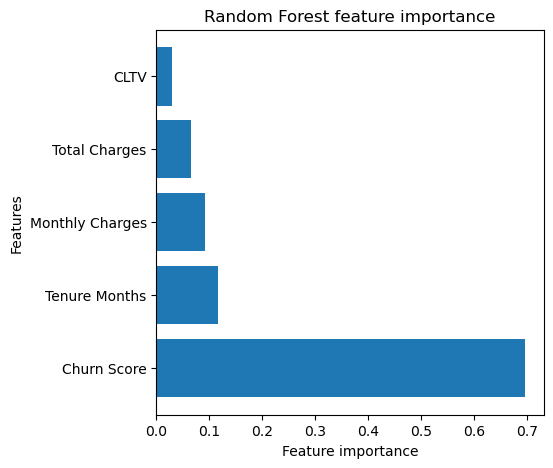

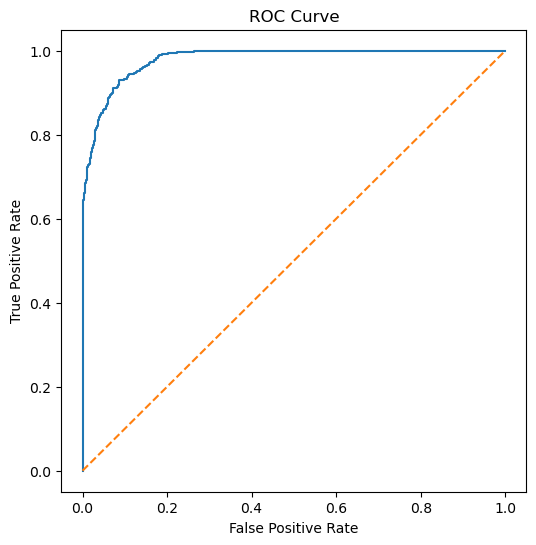

Accuracy Score_RandomForest: 92.50%
Accuracy LogisticRegression: 90.35%
Accuracy Score_Tuned RandomForest: 92.56%
Confusion_matrix for Randomforest: [[1227   67]
 [  65  402]]
Confusion_matrix for LogisticRegression: [[1205   89]
 [  81  386]]
Confusion_matrix for Tuned RandomForest:[[1232   62]
 [  69  398]]
Classification_Report for RandomForest:               precision    recall  f1-score   support

           0       0.95      0.95      0.95      1294
           1       0.86      0.86      0.86       467

    accuracy                           0.93      1761
   macro avg       0.90      0.90      0.90      1761
weighted avg       0.93      0.93      0.93      1761

Classification_Report for LogisticRegression:               precision    recall  f1-score   support

           0       0.94      0.93      0.93      1294
           1       0.81      0.83      0.82       467

    accuracy                           0.90      1761
   macro avg       0.87      0.88      0.88      1761
weig

['Customer_churn_RandomForest.pkl']

In [47]:
#importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report,roc_auc_score,roc_curve
import joblib

#load Data
Churn_data=pd.read_excel('cchurn.xlsx') 
#view data
Churn_data.head()
#dataset info
Churn_data.info()
#shape of data
Churn_data.shape
#check data types
Churn_data.dtypes

#check unique values
Churn_data.nunique()
#check null values
Churn_data.isnull().values.any()
#check duplicate values
Churn_data.duplicated().sum()
#drop removing unwanted columns
Churn_data=Churn_data.drop(columns=['CustomerID','Churn Label','Churn Reason','Count',
                                    'Country','Zip Code','Lat Long','Latitude', 'Longitude',
                                    'Paperless Billing'])

#handle missing values
Churn_data['Total Charges'] = Churn_data['Total Charges'].mask(Churn_data['Total Charges'].astype(str).str.strip() == '',np.nan) #replacing blank strings with nan
Churn_data['Total Charges']= pd.to_numeric(Churn_data['Total Charges'],errors='coerce') #convert to numeric
Churn_data['Total Charges']= Churn_data['Total Charges'].fillna(Churn_data['Total Charges'].median())

#statistics summary
Churn_data.describe()
# EDA
# identify relationships
corr=Churn_data.corr(numeric_only=True)
Churn_percentage= Churn_data['Churn Value'].mean() *100
print(f"churn percentage:{Churn_percentage:.2f} %")

#plot in headmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
#Ditribution data
plt.hist(Churn_data['Monthly Charges'], bins=20)
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly charges')
plt.show()
#outliers
plt.figure(figsize=(8, 2))
plt.boxplot(Churn_data['Total Charges'], vert=False)
plt.title('Box Plot of Total Charges')
plt.show()

#skew
print(f"Skewness: {Churn_data['Total Charges'].skew()}")

#split data
features = [
    'Tenure Months',
    'Monthly Charges',
    'Total Charges',
    'Churn Score',
    'CLTV'
]

x = Churn_data[features]
y = Churn_data['Churn Value']
#one-hot encoding
x = pd.get_dummies(x, drop_first=True)

x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.25,random_state=42,stratify=y)
 
#scaler=StandardScaler()
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#train on LogisticRegression
logr= LogisticRegression(max_iter=2500)
logr.fit(x_train_scaled, y_train)
#predict on model2
y_pred_logr=logr.predict(x_test_scaled)

#train on model- RandomForest
ranfor= RandomForestClassifier(n_estimators=100,
    random_state=42)
ranfor.fit(x_train, y_train)

y_pred_ranfor=ranfor.predict(x_test)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
#Tune the Random Forest hyperparameters
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=5,        
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
random_search.fit(x_train, y_train)

# Get best model
model_trf = random_search.best_estimator_
y_pred_trf = model_trf.predict(x_test)
best_probs = model_trf.predict_proba(x_test)[:, 1]

print(random_search.best_params_)
print(random_search.best_score_)

# Feature importance
top_n=10
importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": model_trf.feature_importances_
})
importance.sort_values(
    by='Importance',
    ascending=False
).head(15)
top_importance=importance.nlargest(top_n,'Importance')
plt.figure(figsize=(5,5))
plt.barh(top_importance['Feature'],top_importance['Importance'])
plt.xlabel('Feature importance')
plt.ylabel('Features')
plt.title("Random Forest feature importance")
plt.show()

#ROC Curve
RandomForest_probs = model_trf.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, RandomForest_probs)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show() 

#evaluation metrics
print(f"Accuracy Score_RandomForest: {accuracy_score(y_test,y_pred_ranfor) *100:.2f}%")
print(f"Accuracy LogisticRegression: {accuracy_score(y_test, y_pred_logr) *100:.2f}%")
print(f"Accuracy Score_Tuned RandomForest: {accuracy_score(y_test, y_pred_trf) * 100:.2f}%")
print(f"Confusion_matrix for Randomforest: {confusion_matrix(y_test,y_pred_ranfor)}")
print(f"Confusion_matrix for LogisticRegression: {confusion_matrix(y_test, y_pred_logr)}")
print(f"Confusion_matrix for Tuned RandomForest:{confusion_matrix(y_test, y_pred_trf)}")
print(f"Classification_Report for RandomForest: {classification_report(y_test,y_pred_ranfor)}")
print(f"Classification_Report for LogisticRegression: {classification_report(y_test,y_pred_logr)}")
print(f"Classification_Report for Tuned RandomForest: {classification_report(y_test,y_pred_trf)}")
print("ROC AUC:", roc_auc_score(y_test, best_probs))

top_n=10
# Predictions
def predict_churn(new_customer):
    new_customer = pd.get_dummies(new_customer, drop_first=True)
    new_customer = new_customer.reindex(columns=x.columns, fill_value=0)

    prediction = model_trf.predict(new_customer)
    probability = model_trf.predict_proba(new_customer)

    print("Prediction:", prediction[0])
    print("Probability:", probability[0][1])
#save the model
joblib.dump(model_trf,'Customer_churn_RandomForest.pkl')


In [42]:
import os
print(os.getcwd())

C:\Users\admin


In [43]:
import os
print(os.listdir())

['.anaconda', '.cache', '.conda', '.condarc', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.kaggle', '.local', '.matplotlib', '.ms-ad', '.streamlit', '.TurboVPN', '.vscode', '.vscode-shared', 'anaconda3', 'AppData', 'Application Data', 'cchurn.xlsx', 'churn.ipynb', 'churn_prediction', 'Contacts', 'Cookies', 'Customer_churn_RandomForest.pkl', 'Documents', 'Downloads', 'Favorites', 'grocery_sales', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2594ee63-d00d-11ef-9d07-ff8b1030571a}.TM.blf', 'NTUSER.DAT{2594ee63-d00d-11ef-9d07-ff8b1030571a}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2594ee63-d00d-11ef-9d07-ff8b1030571a}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates']
